### Data Cleaning and Feature Creation

In [1]:
import pandas as pd
import pickle as pkl

from sklearn.model_selection import train_test_split

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

from sklearn.ensemble import RandomForestClassifier

In [2]:
df = pkl.load(open("../../../data/2021/interim/vbac/vbac_df.pkl", "rb"))

For simplicity, we'll create a feature called `successful_vbac` and use it as our target.

In [3]:
df["successful_vbac"] = df.apply(
    lambda row: 1 if row["delivery_method_recode_7"] == 2 else 0, axis=1
)

df["successful_vbac"].info()

<class 'pandas.Series'>
Index: 562593 entries, 11 to 3669916
Series name: successful_vbac
Non-Null Count   Dtype
--------------   -----
562593 non-null  int64
dtypes: int64(1)
memory usage: 8.6 MB


Our dataset includes many features that are irrelevant to our goal. We'll clean up our features by dropping a few different subsets of features, starting with any features that indicate that another feature has been imputed.

In [4]:
flag_column_names = df.filter(regex="(.*imputed.*|.*flag.*)$", axis=1).columns

flag_column_names_list = flag_column_names.to_list()

We'll also remove features that are recorded after the birth of the child, such as APGAR scores and details about the particulars of the birth and recovery period.

In [5]:
unrelated_features = [
    "marital_status",
    "cigarette_recode",
    "previous_cesarean",
    "final_route_and_method_of_delivery",
    "five_minute_apgar_score",
    "five_minute_apgar_recode",
    "ten_minute_apgar_score",
    "ten_minute_apgar_score_recode",
    "plurality_recode",
    "set_order_recode",
    "last_normal_menses_month",
    "last_normal_menses_year",
    "obstetric_estimate_edited",
    "assisted_ventilation_immediate",
    "assisted_ventilation_after_6_hours",
    "admission_to_nicu",
    "surfactant",
    "antibiotics_for_newborn",
    "seizures",
    "no_abnormal_conditions_reported",
    "infant_transferred",
    "infant_living_at_time_of_report",
    "infant_breastfed_at_discharge",
    "month_prenatal_care_started",
    "no_maternal_comorbidity_reported",
    "perineal_laceration",
    "ruptured_uterus",
    "total_birth_order_recode",
    "unplanned_hysterectomy",
    "maternal_transfusion",
    "mother_transferred",
    "admit_to_intensive_care",
    "live_birth_order_recode",
]

df_filtered = df.drop(flag_column_names_list, axis="columns").drop(
    unrelated_features, axis="columns"
)

Of the remaining features, a few have NA values, so we'll drop those rows.

In [6]:
df_filtered = df_filtered.dropna(
    subset=[
        "WIC",
        "gonorrhea",
        "syphilis",
        "chlamydia",
        "hepatitis_b",
        "hepatitis_c",
        "successful_external_cephalic_version",
        "failed_external_cephalic_version",
        "induction_of_labor",
        "augmentation_of_labor",
        "steroids",
        "antibiotics",
        "chorioamnionitis",
        "anesthesia",
        "anencephaly",
        "spina_bifida",
        "cyanotic_congenital_heart_disease",
        "congenital_diaphragmatic_hernia",
        "omphalocele",
        "gastroschisis",
        "limb_reduction_defect",
        "cleft_lip",
        "cleft_palate",
        "down_syndrome",
        "suspected_chromosomal_disorder",
        "hypospadias",
        "no_congenital_abnormalities_reported",
    ]
)

In [7]:
pkl.dump(df_filtered, open("../../../data/2021/processed/vbac/filtered_df.pkl", "wb"))

Finally, we will extract our target value and drop any column with 1-1 correlation to it.

In [8]:
successful_vbac = df_filtered["successful_vbac"]

df_filtered = df_filtered.drop(
    ["delivery_method_recode_7", "delivery_method_recode_3", "successful_vbac"],
    axis="columns",
)

In [9]:
df_filtered.info()

<class 'pandas.DataFrame'>
Index: 553932 entries, 11 to 3669916
Columns: 104 entries, birth_month to no_congenital_abnormalities_reported
dtypes: float64(34), int16(7), int8(63)
memory usage: 188.6 MB


Because successful VBAC comprises only a small portion of our populaiton, we'll stratify our train-test split.

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    df_filtered,
    successful_vbac,
    train_size=0.8,
    random_state=14,
    stratify=successful_vbac,
)

We'll create a categorical and a numerical pipeline for data transformation.

In [32]:
cat_features = [
    "birth_month",
    "birth_day_of_week",
    "birth_place",
    "facility_recode",
    "mothers_age_recode_14",
    "mothers_age_recode_9",
    "mothers_nativity",
    "mothers_residence_status",
    "mothers_race_recode_31",
    "mothers_race_recode_6",
    "mothers_race_recode_15",
    "mothers_hispanic_origin",
    "mothers_hispanic_origin_recode",
    "mothers_race_and_hispanic_origin",
    "mothers_education",
    "fathers_age_recode_11",
    "fathers_race_recode_31",
    "fathers_race_recode_6",
    "fathers_race_recode_15",
    "fathers_hispanic_origin",
    "fathers_hispanic_origin_recode",
    "fathers_race_and_hispanic_origin",
    "fathers_education",
    "interval_since_last_live-birth_recode_11",
    "interval_since_last_other_pregnancy_recode_11",
    "interval_since_last_pregnancy_recode_11",
    "month_prenatal_care_began_recode",
    "number_of_prenatal_visits_recode",
    "WIC",
    "BMI_recode",
    "cigarettes_before_pregnancy_recode",
    "cigarettes_first_trimester_recode",
    "cigarettes_second_trimester_recode",
    "cigarettes_third_trimester_recode",
    "pre_pregnancy_diabetes",
    "gestational_diabetes",
    "pre_pregnancy_hypertension",
    "gestational_hypertension",
    "hypertension_eclampsia",
    "previous_preterm_birth",
    "infertility_treatment_used",
    "no_risk_factors_reported",
    "gonorrhea",
    "syphilis",
    "chlamydia",
    "hepatitis_b",
    "hepatitis_c",
    "no_infection_present",
    "successful_external_cephalic_version",
    "failed_external_cephalic_version",
    "induction_of_labor",
    "augmentation_of_labor",
    "steroids",
    "antibiotics",
    "chorioamnionitis",
    "anesthesia",
    "no_characteristics_of_labor_reported",
    "fetal_presentation_at_delivery",
    "attendant_at_birth",
    "payment_source_for_delivery",
    "payment_recode",
    "sex_of_infant",
    "combined_gestation_recode_10",
    "combined_gestation_recode_3",
    "obstetric_estimate_recode_10",
    "obstetric_estimate_recode_3",
    "birth_weight_recode_12",
    "birth_weight_recode_4",
    "anencephaly",
    "spina_bifida",
    "cyanotic_congenital_heart_disease",
    "congenital_diaphragmatic_hernia",
    "omphalocele",
    "gastroschisis",
    "limb_reduction_defect",
    "cleft_lip",
    "cleft_palate",
    "down_syndrome",
    "suspected_chromosomal_disorder",
    "hypospadias",
    "no_congenital_abnormalities_reported",
]

In [33]:
cat_pipeline = make_pipeline(
    SimpleImputer(missing_values=pd.NA, strategy="most_frequent"),
    OneHotEncoder(drop="first", sparse_output=True, handle_unknown="ignore"),
)

In [34]:
num_features = [
    "time_of_birth",
    "mothers_single_year_age",
    "fathers_combined_age",
    "prior_births_now_living",
    "prior_births_now_dead",
    "prior_other_terminations",
    "interval_since_last_live_birth",
    "interval_since_last_other_pregnancy_recode",
    "interval_since_last_pregnancy_recode",
    "number_of_prenatal_visits",
    "cigarettes_before_pregnancy",
    "cigarettes_first_trimester",
    "cigarettes_second_trimester",
    "cigarettes_third_trimester",
    "pre_pregnancy_weight_recode",
    "weight_gain_recode",
    "delivery_weight_recode",
    "mothers_height_in_inches",
    "BMI",
    "weight_gain",
    "number_of_previous_cesarean",
    "combined_gestation_detail_in_weeks",
    "birth_weight_in_grams",
]

In [35]:
num_pipeline = make_pipeline(
    SimpleImputer(missing_values=pd.NA, strategy="mean"), StandardScaler()
)

In [36]:
preprocessing = ColumnTransformer(
    [
        ("Categorical Pipeline", cat_pipeline, cat_features),
        ("Numerical Pipeline", num_pipeline, num_features),
    ]
)

In [37]:
X_train_prepared = preprocessing.fit_transform(X_train, y_train)
X_test_prepared = preprocessing.transform(X_test)

/home/akrucken/dev/natality-stats/dev/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [8] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


We now have a transformed dataset.

In [38]:
X_train_prepared.shape

(443145, 404)

We are not confident that all these features will prove to be highly relevant to our model, so we will use a Random Forest to narrow down our features based on importance.

In [39]:
feature_selector = RandomForestClassifier(random_state=14, max_depth=5)

feature_selector.fit(X_train_prepared, y_train)

feature_importances = feature_selector.feature_importances_

In [40]:
feature_importances_df = pd.DataFrame(
    {
        "feature": preprocessing.get_feature_names_out(),
        "importance": feature_importances,
    }
).sort_values("importance", ascending=False)

feature_importances_df.head(20)

,feature,importance
302,Categorical Pipeline__augmentation_of_labor_1.0,0.191325
301,Categorical Pipeline__induction_of_labor_1.0,0.135495
312,Categorical Pipeline__attendant_at_birth_3.0,0.135059
346,Categorical Pipeline__obstetric_estimate_recod...,0.096500
381,Numerical Pipeline__time_of_birth,0.071971
401,Numerical Pipeline__number_of_previous_cesarean,0.059836
24,Categorical Pipeline__facility_recode_2.0,0.034360
402,Numerical Pipeline__combined_gestation_detail_...,0.033859
18,Categorical Pipeline__birth_place_3.0,0.029403
384,Numerical Pipeline__prior_births_now_living,0.026401


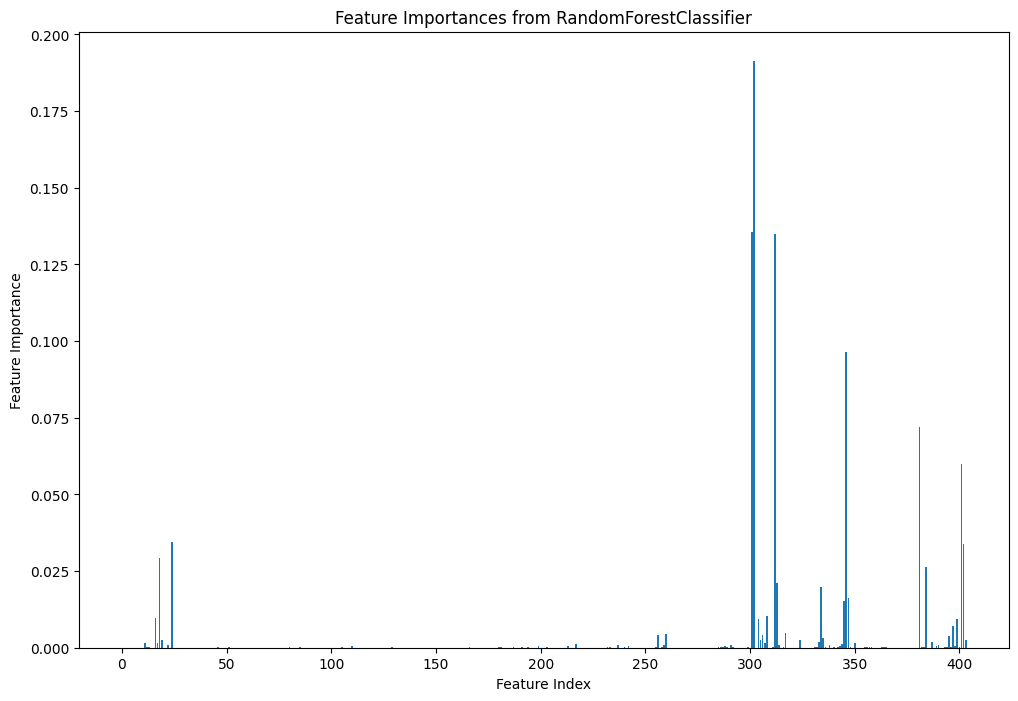

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plt.bar(range(len(feature_importances)), feature_importances)
plt.xlabel("Feature Index")
plt.ylabel("Feature Importance")
plt.title("Feature Importances from RandomForestClassifier")
plt.show()

We'll save the feature importances to a file so it can be used to filter our train and test sets in different configurations.

In [42]:
pkl.dump(
    feature_importances_df,
    open("../../../data/2021/processed/vbac/feature_importances_df.pkl", "wb"),
)